Creat the variable that will hold the data sets for the classification (N se mexe)

In [183]:
from sklearn.datasets import make_classification,make_regression,make_circles,make_moons,make_blobs
import numpy as np
import pandas as pd
datasets_classification = []
def generate_datasets_classification(n_samples, n_features, n_informative, n_redundant, n_repeated, n_classes, 
                      n_clusters_per_class, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, 
                      shift=0.0, scale=1.0, shuffle=True, random_state=None):
    
    X, Y = make_classification(n_samples=n_samples, n_features=n_features, n_informative=n_informative, 
                               n_redundant=n_redundant, n_repeated=n_repeated, n_classes=n_classes, 
                               n_clusters_per_class=n_clusters_per_class, weights=weights, flip_y=flip_y, 
                               class_sep=class_sep, hypercube=hypercube, shift=shift, scale=scale, 
                               shuffle=shuffle, random_state=random_state)
    datasets_classification.append((X, Y))
def generate_datasets_classification_circles(n_samples,shuffle=True, noise=None, factor=0.8, random_state=42):

    X, Y = make_circles(n_samples=n_samples,shuffle=shuffle, noise=noise, factor=factor, random_state=random_state)

    datasets_classification.append((X, Y))

def generate_datasets_classification_moons(n_samples, shuffle=True, noise=None, random_state=None):
    
    X, Y = make_moons(n_samples=n_samples, shuffle=shuffle, noise=noise, random_state=random_state)

    datasets_classification.append((X,Y))
def generate_datasets_regression_blobs(n_samples,n_features,centers=None, cluster_std=1.0, 
                                       center_box=(-10.0, 10.0), shuffle=True, random_state=None, 
                                       return_centers=False):
    
    X, Y = make_blobs(n_samples=n_samples,n_features=n_features,centers=centers,cluster_std=cluster_std, 
                      center_box=center_box,shuffle=shuffle, random_state=random_state,return_centers=return_centers)
    
    datasets_classification.append((X,Y))

    


datasets_regression = []
def generate_datasets_regression( n_samples, n_features, n_informative,n_targets = 1,bias = 0,effective_rank=None, tail_strength=0.5, 
                                 noise=0.0, shuffle=True, coef=False, random_state=None ):

    X, Y= make_regression(n_samples=n_samples, n_features=n_features,n_informative=n_informative,n_targets=n_targets, bias = bias,
                          effective_rank =effective_rank, tail_strength=tail_strength, noise=noise, shuffle=shuffle, coef=coef, 
                          random_state=random_state)
    datasets_regression.append((X, Y))

   



Fill the "dataset_classification" variable with  diferent datasets using diferent the parameters (The first being the defaut)(Mexer aqui nos valores dos parametros e escolher se se quer classification or regression)

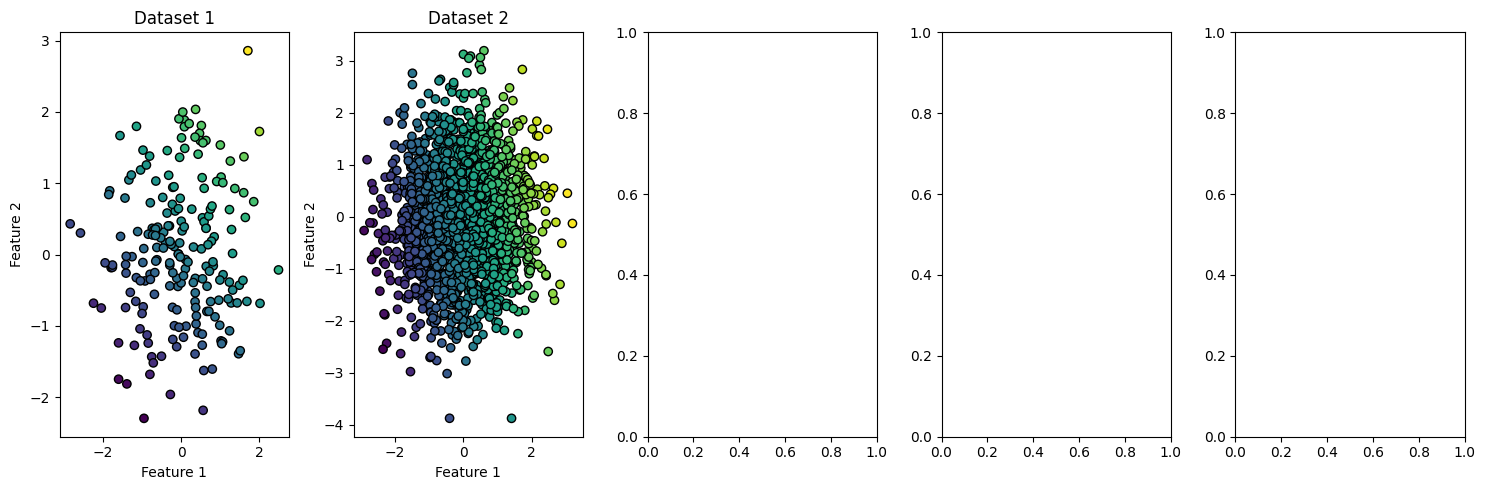

In [184]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate classification

generate_datasets_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=1, n_repeated=0, n_classes=2, 
                      n_clusters_per_class=2, weights=None, flip_y=0.6, class_sep=2.0, hypercube=True, shift=0.0, 
                      scale=1.0, shuffle=True, random_state=42),
generate_datasets_classification_moons(n_samples=1000, noise=0.2,random_state=0),
generate_datasets_classification(n_samples=2000, n_features=2, n_informative=2, n_redundant=0, n_repeated=0, n_classes=2, 
                      n_clusters_per_class=1, weights=[0.9,0.1], flip_y=0.4, class_sep=2, hypercube=True, shift=0.0, 
                      scale=1.0, shuffle=True, random_state=42)
generate_datasets_classification_circles(n_samples=2000,noise=0,factor=0.8, random_state=42)
generate_datasets_regression_blobs(n_samples=500, centers=2,cluster_std=1, n_features=2, random_state=None)

# Generate regression
generate_datasets_regression(n_samples=200, n_features=2, n_informative=2)
generate_datasets_regression(n_samples=2000, n_features=4, n_informative=2,tail_strength=1,noise=1)

#choose classification or regression datasets
task_type = "regression"  # Change to "regression" to use regression datasets

if task_type == "classification":
    dataset = datasets_classification
else:
    dataset = datasets_regression


# Plot the datasets
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i, (X, Y) in enumerate(dataset):
    axes[i].scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolor='k')
    axes[i].set_title(f"Dataset {i+1}")
    axes[i].set_xlabel("Feature 1")
    axes[i].set_ylabel("Feature 2")
plt.tight_layout()
plt.show()


Choice of the method and the dataset in análise(escolher o dataset a ser analisado agora(para ja so dá um de cada vez) e o metodo dentro dos que tao comentados em cima)

In [185]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
mean_squared_error, r2_score, mean_absolute_error)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
# Apply SVM with linear kernel only to the last dataset
X, Y = dataset[0] # here decide wich dataset to use
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#DecisionTreeClassifier()
#DecisionTreeClassifier(max_depth=2)
#LogisticRegression()
#LDA()
#QDA()
#SVC(kernel='linear')
#SVC(kernel='rbf')

model = DecisionTreeRegressor(max_depth=3)
if task_type == "classification":
   
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    # Classification Metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    recall = recall_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred)

    print(f"Model Accuracy: {accuracy:.2f} | F1: {f1:.2f} | Recall: {recall:.2f} | Precision: {precision:.2f}")

elif task_type == "regression":
    
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)

    # Regression Metrics
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)
    mae = mean_absolute_error(Y_test, Y_pred)

    print(f"Mean Squared Error: {mse:.2f} | R2 Score: {r2:.2f} | MAE: {mae:.2f}")

Mean Squared Error: 653.07 | R2 Score: 0.84 | MAE: 17.27


Function for ploting the decision boundary(n é preciso mexer)

In [ ]:
def plot_results(model, X, Y):
    if task_type == "classification":
        # Only plot decision boundary for 2D classification datasets
        if X.shape[1] == 2:
            xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                                 np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)

            plt.figure(figsize=(6, 5))
            plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
            plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolor='k')
            plt.xlabel("Feature 1")
            plt.ylabel("Feature 2")
            plt.title("Decision Boundary")
            plt.show()

    elif task_type == "regression":
        # Regression: Plot actual vs predicted values
        plt.figure(figsize=(6, 5))
        plt.scatter(Y_test, Y_pred, color='blue', edgecolor='k', alpha=0.6)
        plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # Perfect prediction line
        plt.xlabel("Actual Values")
        plt.ylabel("Predicted Values")
        plt.title("Regression: Actual vs Predicted")
        plt.show()





ROC curve plus Confusion Matrix( n é preciso mexer)

In [ ]:
from sklearn.metrics import roc_curve, auc,confusion_matrix, ConfusionMatrixDisplay

def plot_roc_curve(model, X_test, Y_test):
    if hasattr(model, "decision_function"):
        Y_score = model.decision_function(X_test)
    else:
        Y_score = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(Y_test, Y_score)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

def plot_confusion_matrix(Y_test, Y_pred):
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()



# Plot ROC curve
plot_roc_curve(model, X_test, Y_test)

# Plot Confusion Matrix
plot_confusion_matrix(Y_test, Y_pred)






AttributeError: 'DecisionTreeRegressor' object has no attribute 'predict_proba'

In [193]:
# Fixar seed para reprodutibilidade
np.random.seed(42)

# Lista de datasets
datasets = {}

# 1️⃣ Número de instâncias (pequeno e grande)
datasets["Small (200 pts)"] = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
datasets["Large (1000 pts)"] = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# 2️⃣ Número de classes (2, 3 e 4)
datasets["2 Classes"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
datasets["3 Classes"] = make_blobs(n_samples=500, centers=3, n_features=2, random_state=42)
datasets["4 Classes"] = make_blobs(n_samples=500, centers=4, n_features=2, random_state=42)

# 3️⃣ Proporção de classes (Balanceado e Desbalanceado)
datasets["Balanced"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, weights=[0.5, 0.5], random_state=42)
datasets["Imbalanced (90-10)"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, weights=[0.9, 0.1], random_state=42)

# 4️⃣ Distribuição dos pontos (Gaussian, Circular, Moons)
datasets["Gaussian"] = make_blobs(n_samples=500, centers=2, cluster_std=1.0, random_state=42)
datasets["Circular"] = make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
datasets["Moons"] = make_moons(n_samples=500, noise=0.2, random_state=42)

# 5️⃣ Forma da fronteira (Linear vs. Não Linear)
datasets["Linear Border"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, class_sep=2.0, random_state=42)
datasets["Non-Linear Border"] = make_moons(n_samples=500, noise=0.2, random_state=42)

# 6️⃣ Nível de Ruído (0, 10%, 30%)
datasets["No Noise"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, flip_y=0.0, random_state=42)
datasets["10% Noise"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, flip_y=0.1, random_state=42)
datasets["30% Noise"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, flip_y=0.3, random_state=42)

# 7️⃣ Sobreposição entre classes (Separação alta vs. baixa)
datasets["High Separation"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, class_sep=2.5, random_state=42)
datasets["Low Separation"] = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0, class_sep=0.5, random_state=42)


📊 Dataset: Small (200 pts)
🔹 Decision Tree: Accuracy: 0.87 | Precision: 0.87 | Recall: 0.87 | F1-score: 0.87
🔹 Decision Tree (depth=2): Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87
🔹 Logistic Regression: Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87
🔹 LDA: Accuracy: 0.88 | Precision: 0.90 | Recall: 0.88 | F1-score: 0.88
🔹 QDA: Accuracy: 0.85 | Precision: 0.87 | Recall: 0.85 | F1-score: 0.85
🔹 SVC (linear): Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87
🔹 SVC (rbf): Accuracy: 0.85 | Precision: 0.86 | Recall: 0.85 | F1-score: 0.85


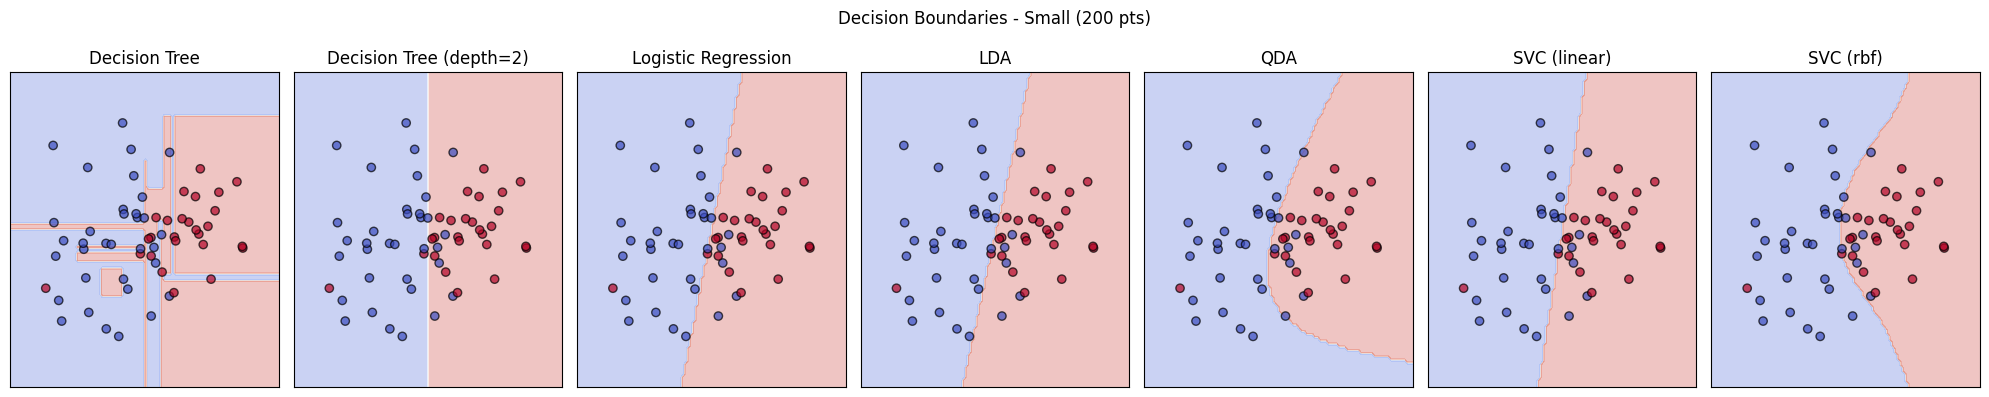

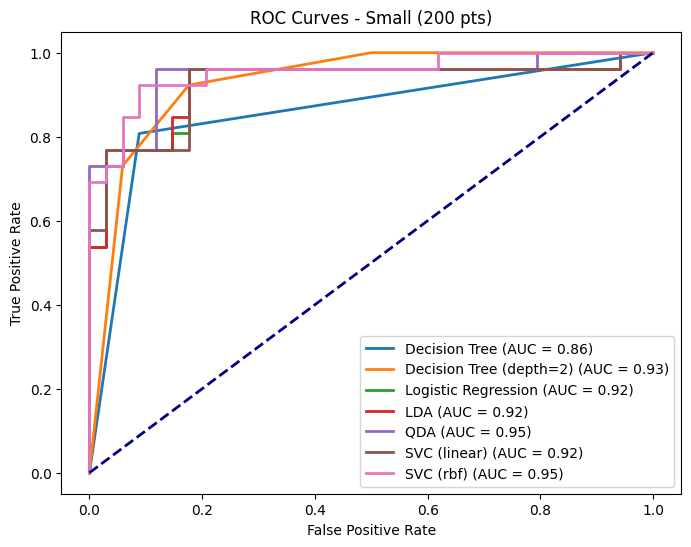

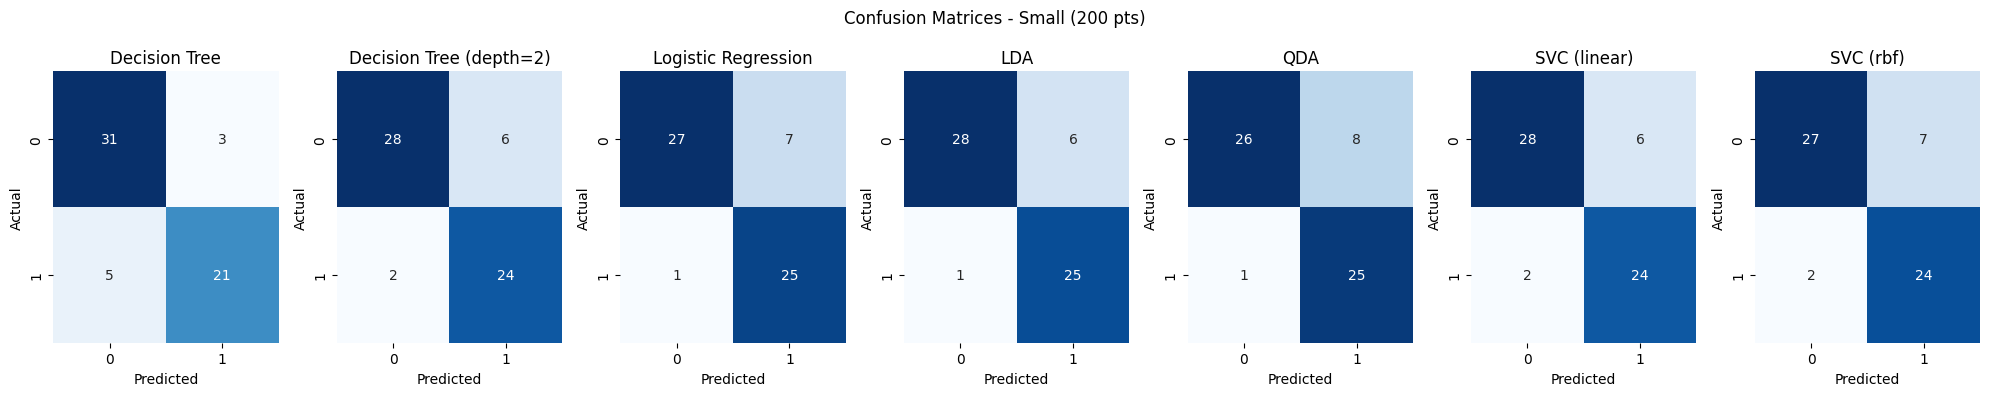


📊 Dataset: Large (1000 pts)
🔹 Decision Tree: Accuracy: 0.94 | Precision: 0.94 | Recall: 0.94 | F1-score: 0.94
🔹 Decision Tree (depth=2): Accuracy: 0.93 | Precision: 0.93 | Recall: 0.93 | F1-score: 0.93
🔹 Logistic Regression: Accuracy: 0.88 | Precision: 0.89 | Recall: 0.88 | F1-score: 0.88
🔹 LDA: Accuracy: 0.89 | Precision: 0.89 | Recall: 0.89 | F1-score: 0.89
🔹 QDA: Accuracy: 0.94 | Precision: 0.94 | Recall: 0.94 | F1-score: 0.94
🔹 SVC (linear): Accuracy: 0.91 | Precision: 0.92 | Recall: 0.91 | F1-score: 0.91
🔹 SVC (rbf): Accuracy: 0.92 | Precision: 0.93 | Recall: 0.92 | F1-score: 0.92


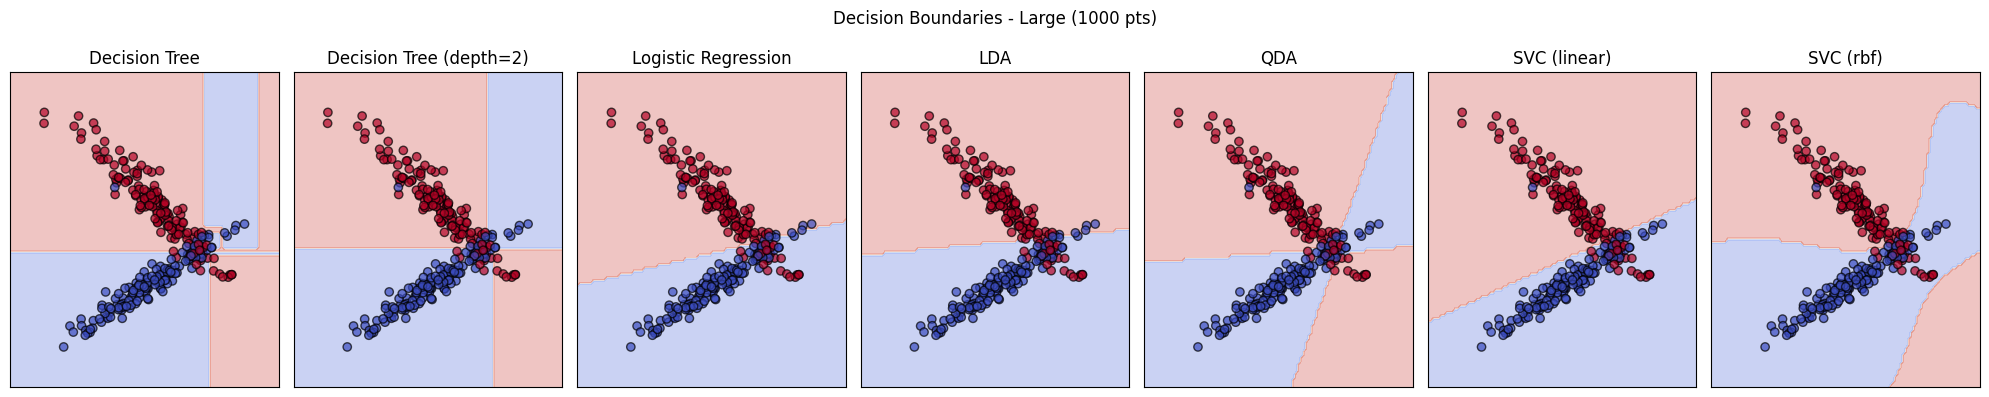

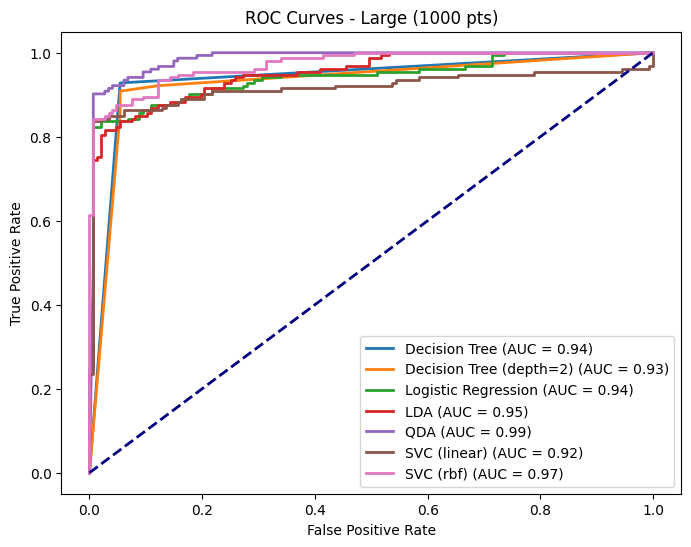

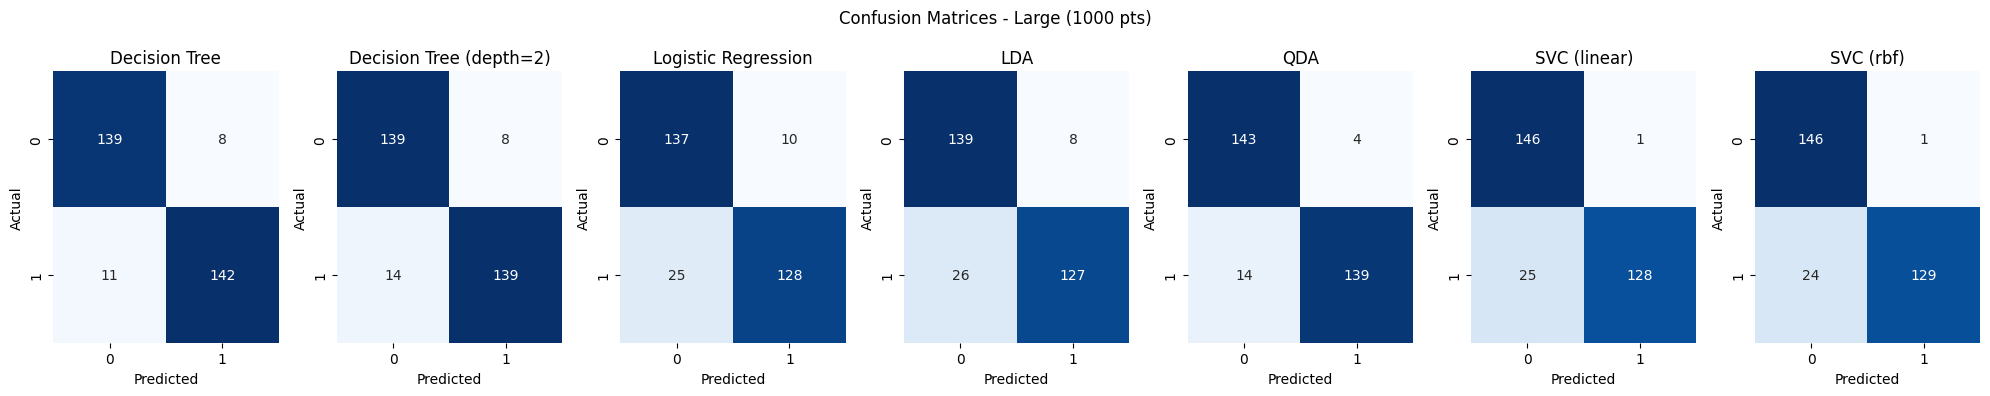


📊 Dataset: 2 Classes
🔹 Decision Tree: Accuracy: 0.93 | Precision: 0.93 | Recall: 0.93 | F1-score: 0.93
🔹 Decision Tree (depth=2): Accuracy: 0.91 | Precision: 0.91 | Recall: 0.91 | F1-score: 0.91
🔹 Logistic Regression: Accuracy: 0.85 | Precision: 0.85 | Recall: 0.85 | F1-score: 0.85
🔹 LDA: Accuracy: 0.86 | Precision: 0.86 | Recall: 0.86 | F1-score: 0.86
🔹 QDA: Accuracy: 0.95 | Precision: 0.95 | Recall: 0.95 | F1-score: 0.95
🔹 SVC (linear): Accuracy: 0.85 | Precision: 0.85 | Recall: 0.85 | F1-score: 0.85
🔹 SVC (rbf): Accuracy: 0.93 | Precision: 0.94 | Recall: 0.93 | F1-score: 0.93


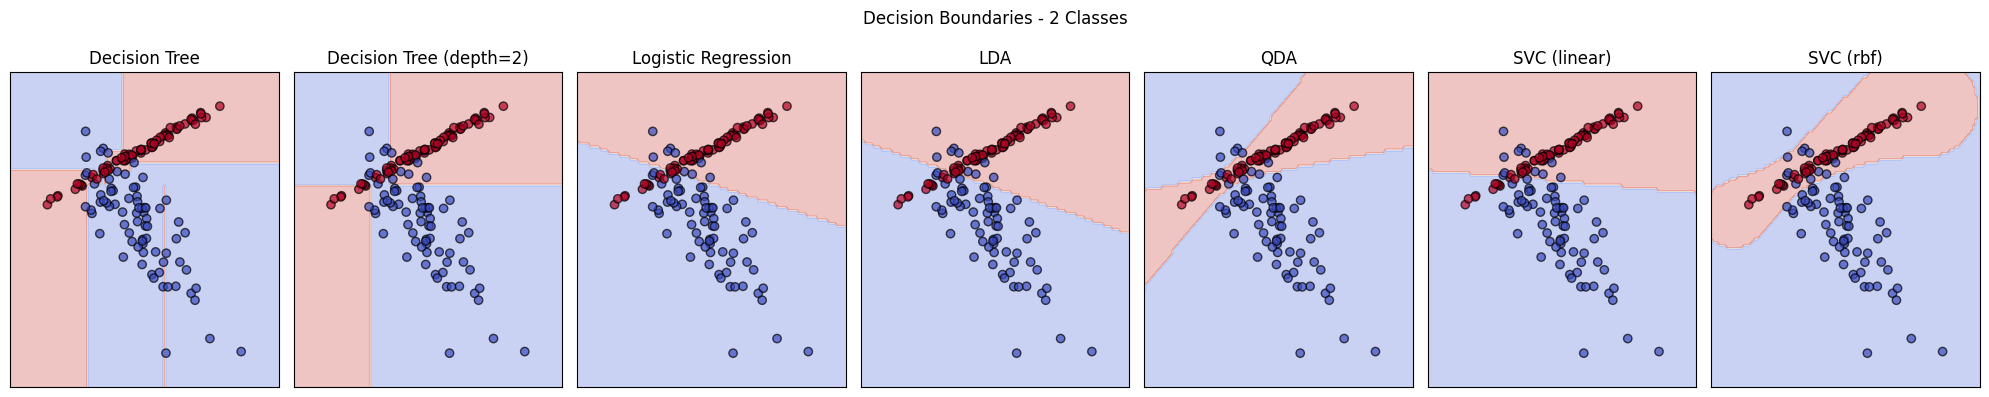

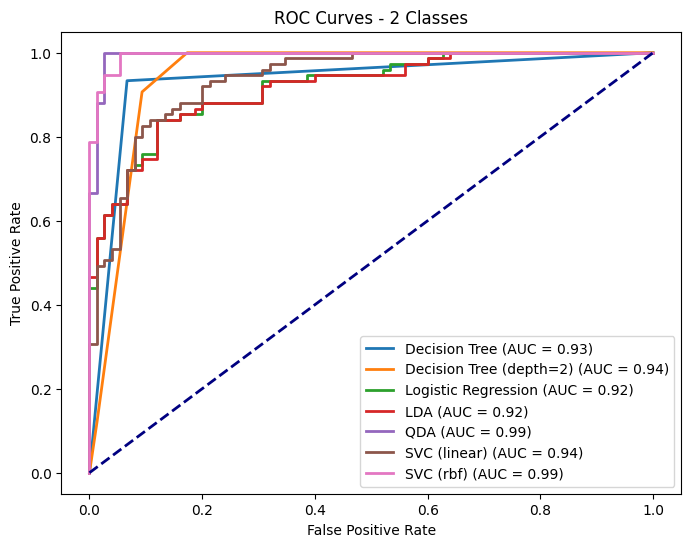

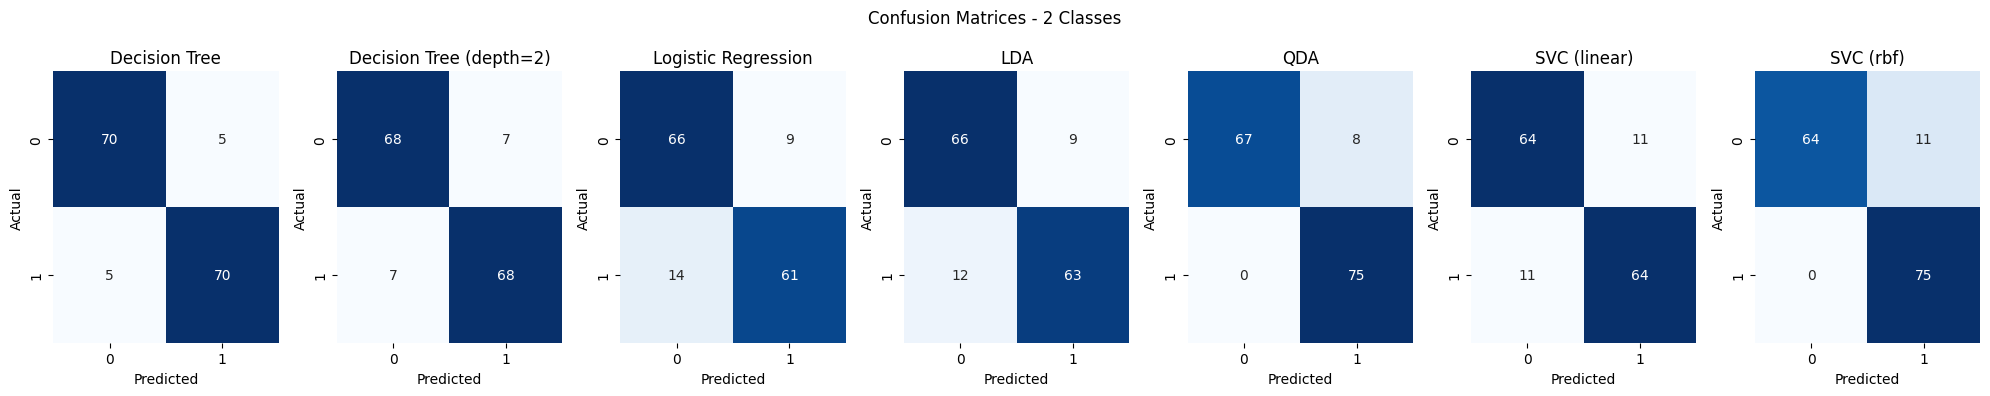


📊 Dataset: 3 Classes
🔹 Decision Tree: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 Decision Tree (depth=2): Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 Logistic Regression: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 LDA: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 QDA: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 SVC (linear): Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 SVC (rbf): Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00


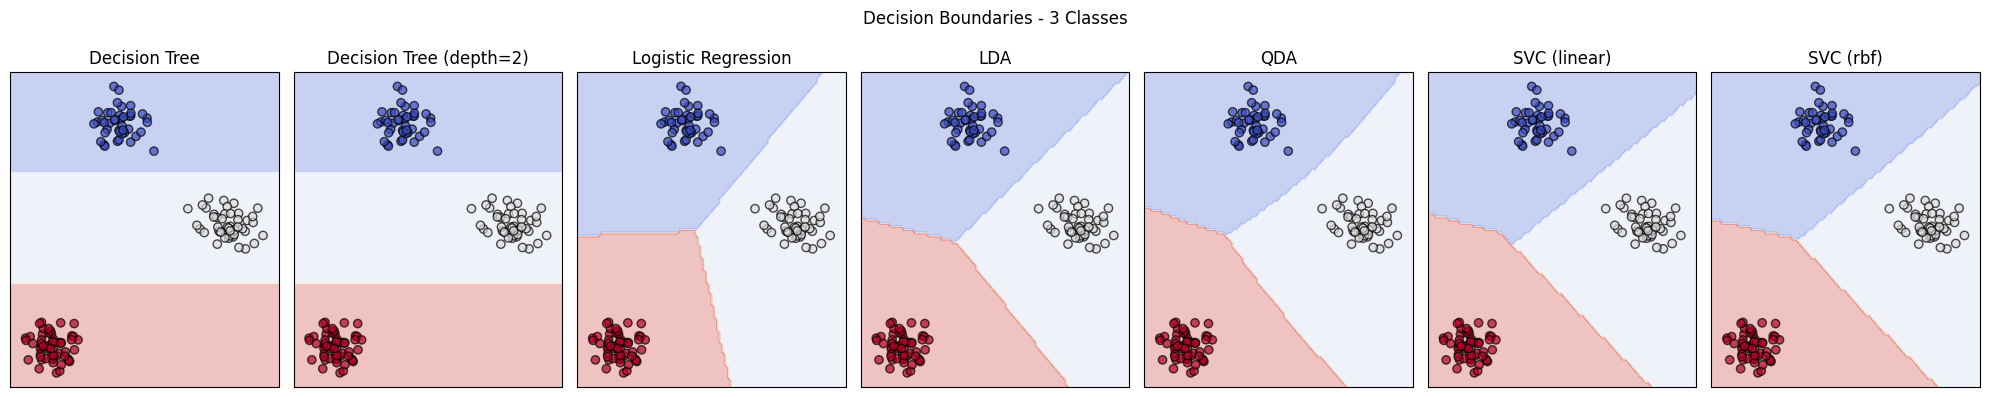

⚠️ Skipping ROC Curve (Multiclass detected) for 3 Classes


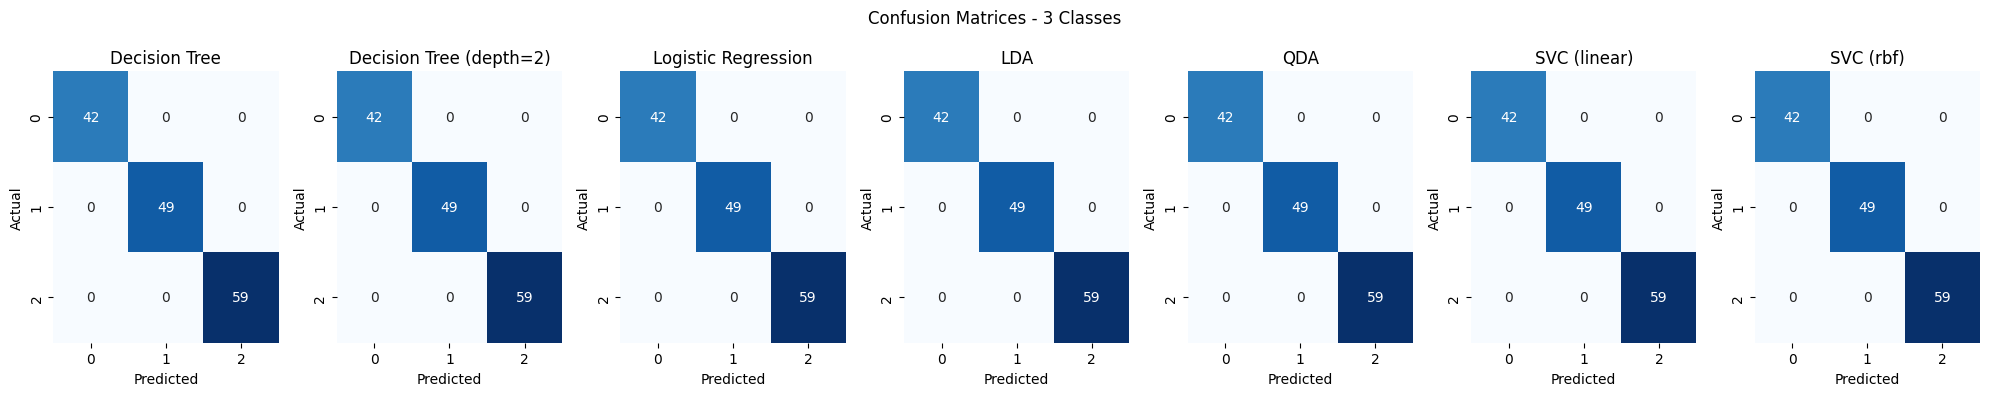


📊 Dataset: 4 Classes
🔹 Decision Tree: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 Decision Tree (depth=2): Accuracy: 0.68 | Precision: 0.55 | Recall: 0.68 | F1-score: 0.59
🔹 Logistic Regression: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 LDA: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 QDA: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 SVC (linear): Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00
🔹 SVC (rbf): Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-score: 1.00


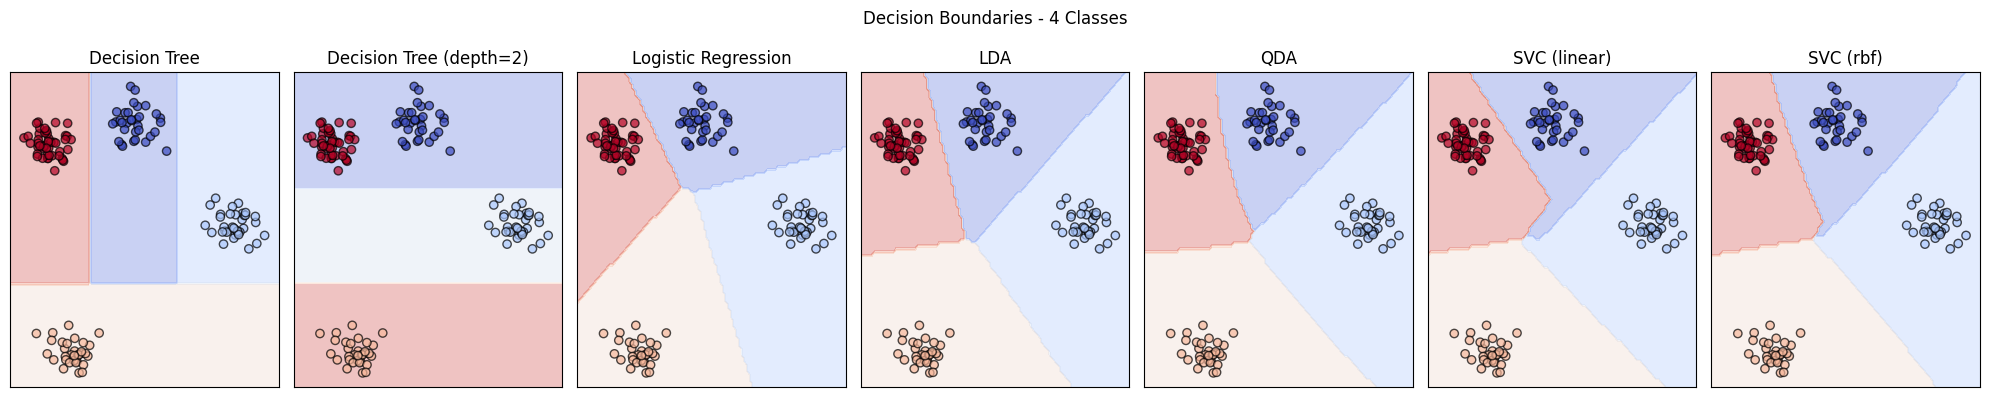

⚠️ Skipping ROC Curve (Multiclass detected) for 4 Classes


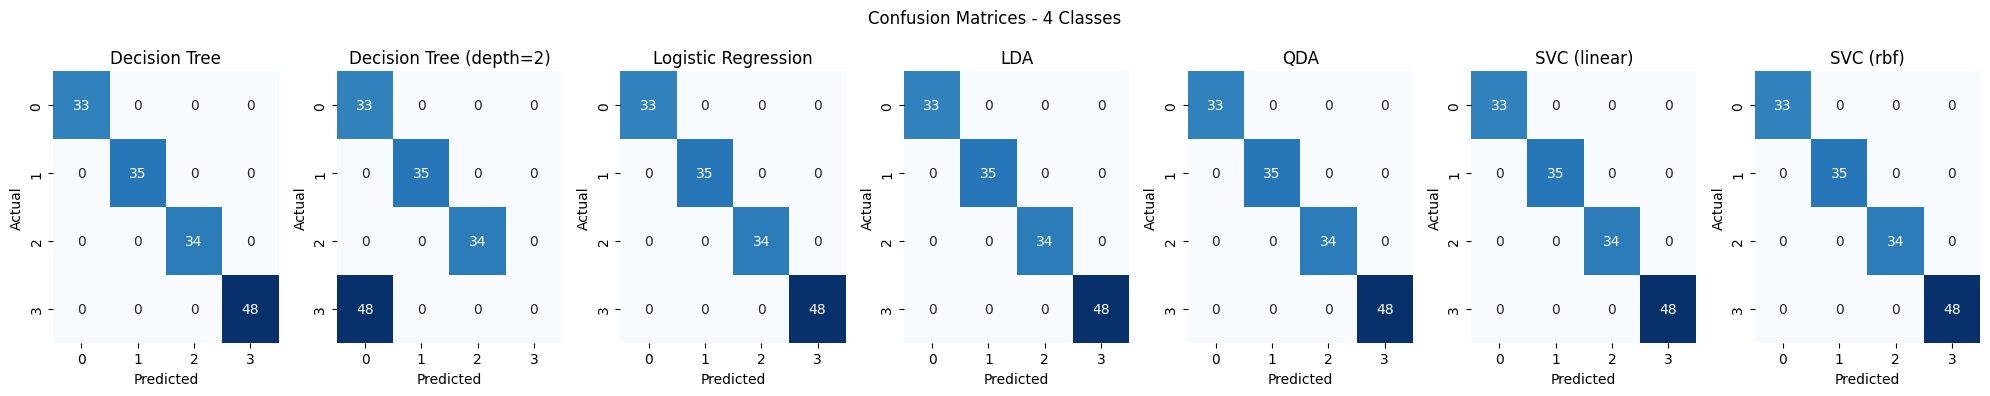


📊 Dataset: Balanced
🔹 Decision Tree: Accuracy: 0.91 | Precision: 0.91 | Recall: 0.91 | F1-score: 0.91
🔹 Decision Tree (depth=2): Accuracy: 0.86 | Precision: 0.88 | Recall: 0.86 | F1-score: 0.86
🔹 Logistic Regression: Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87
🔹 LDA: Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87
🔹 QDA: Accuracy: 0.89 | Precision: 0.89 | Recall: 0.89 | F1-score: 0.89
🔹 SVC (linear): Accuracy: 0.88 | Precision: 0.89 | Recall: 0.88 | F1-score: 0.88
🔹 SVC (rbf): Accuracy: 0.87 | Precision: 0.88 | Recall: 0.87 | F1-score: 0.87


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_moons, make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_curve, auc, confusion_matrix
)
from sklearn.preprocessing import label_binarize


# Classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Decision Tree (depth=2)": DecisionTreeClassifier(max_depth=2),
    "Logistic Regression": LogisticRegression(),
    "LDA": LDA(),
    "QDA": QDA(),
    "SVC (linear)": SVC(kernel='linear', probability=True),
    "SVC (rbf)": SVC(kernel='rbf', probability=True)
}

# Function to plot decision boundaries for all models
def plot_decision_boundaries(models, X_test, y_test, dataset_name):
    fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
    x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
    y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    
    for ax, (name, model) in zip(axes, models.items()):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", edgecolor='k', alpha=0.7)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(f"Decision Boundaries - {dataset_name}")
    plt.tight_layout()
    plt.show()

# Function to plot all ROC curves in the same figure (skip multiclass)
def plot_roc_curves(models, X_test, y_test, dataset_name):
    if len(np.unique(y_test)) > 2:  # Check if dataset is multiclass
        print(f"⚠️ Skipping ROC Curve (Multiclass detected) for {dataset_name}")
        return
    
    plt.figure(figsize=(8, 6))
    
    for name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_score)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {dataset_name}")
    plt.legend(loc="lower right")
    plt.show()

# Function to plot all confusion matrices in the same figure
def plot_confusion_matrices(models, X_test, y_test, dataset_name):
    fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
    
    for ax, (name, model) in zip(axes, models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False, ax=ax)
        ax.set_title(name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.suptitle(f"Confusion Matrices - {dataset_name}")
    plt.tight_layout()
    plt.show()

# Iterate through datasets and classifiers
for dataset_name, (X_train, X_test, y_train, y_test) in datasets_train_test.items():
    print(f"\n📊 Dataset: {dataset_name}")

    trained_models = {}
    
    # Train all classifiers
    for name, model in classifiers.items():
        model.fit(X_train, y_train)
        trained_models[name] = model
        
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_test, y_pred, average="weighted")
        
        print(f"🔹 {name}: Accuracy: {acc:.2f} | Precision: {prec:.2f} | Recall: {rec:.2f} | F1-score: {f1:.2f}")

    # Plot decision boundaries
    plot_decision_boundaries(trained_models, X_test, y_test, dataset_name)

    # Plot ROC curves (skip if multiclass)
    plot_roc_curves(trained_models, X_test, y_test, dataset_name)

    # Plot confusion matrices
    plot_confusion_matrices(trained_models, X_test, y_test, dataset_name)

